# Module 3 — Préparation des images de récifs coralliens

Ce notebook prépare les données du module 3 avant l'entraînement de MobileNetV2.

## Objectifs

1. vérifier les chemins des images ;
2. transformer les 39 labels ReefNet en 4 catégories ;
3. identifier l'image originale de chaque patch ;
4. créer les ensembles train, validation et test sans fuite de données ;
5. calculer les poids des classes ;
6. sauvegarder les fichiers CSV nécessaires à l'entraînement.

## Classes retenues

- `Live_coral` : coraux vivants durs et mous ;
- `Algae` : algues et couverture algale ;
- `Substrate_degraded` : substrat dur, sédiment, rubble, corail mort ou blanchi ;
- `Other_background` : ombre, objets humains, poissons et autres organismes.

> Le dataset utilisé est un jeu ReefNet nommé `TestDataset`. Il est réorganisé ici comme preuve de concept. Les résultats devront être présentés avec cette limite.

In [1]:
from pathlib import Path
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver le dossier data.")

MODULE3_DIR = PROJECT_ROOT / 'data' / 'module3'
IMAGES_ROOT = MODULE3_DIR / 'ReefNet_RSG-TestDataset_images'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module3'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

annotation_candidates = sorted(
    MODULE3_DIR.glob('ReefNet_RSG-TestDataset_annotations*.csv')
)
if not annotation_candidates:
    annotation_candidates = sorted(MODULE3_DIR.glob('*.csv'))

assert annotation_candidates, f'Aucun CSV trouvé dans {MODULE3_DIR}'
ANNOTATIONS_FILE = annotation_candidates[0]

print('Racine du projet :', PROJECT_ROOT)
print('Annotations :', ANNOTATIONS_FILE)
print('Dossier images :', IMAGES_ROOT)
print('Annotations trouvées :', ANNOTATIONS_FILE.exists())
print('Dossier images trouvé :', IMAGES_ROOT.exists())

assert ANNOTATIONS_FILE.exists()
assert IMAGES_ROOT.exists()

Racine du projet : C:\Users\elasr\OneDrive\Desktop\hind
Annotations : C:\Users\elasr\OneDrive\Desktop\hind\data\module3\ReefNet_RSG-TestDataset_annotations.csv
Dossier images : C:\Users\elasr\OneDrive\Desktop\hind\data\module3\ReefNet_RSG-TestDataset_images
Annotations trouvées : True
Dossier images trouvé : True


## 1. Chargement du fichier d'annotations

In [2]:
df = pd.read_csv(ANNOTATIONS_FILE)

required_columns = {'name', 'patch_path', 'label'}
missing = required_columns - set(df.columns)
assert not missing, f'Colonnes manquantes : {sorted(missing)}'

df = df[['name', 'patch_path', 'label']].copy()
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

print('Dimensions :', df.shape)
print('Valeurs manquantes :', int(df.isna().sum().sum()))
print('Noms dupliqués :', int(df['name'].duplicated().sum()))
print('Nombre de labels originaux :', df['label'].nunique())

display(df.head())
display(df['label'].value_counts().to_frame('nombre'))

Dimensions : (17870, 3)
Valeurs manquantes : 0
Noms dupliqués : 0
Nombre de labels originaux : 39


,name,patch_path,label
0,COSA01_CENTERA_IMG_1582_20220317.JPG_1.png,/patches/COSA01_CENTERA_IMG_1582_20220317.JPG_...,Hard substrate
1,COSA01_CENTERA_IMG_1582_20220317.JPG_2.png,/patches/COSA01_CENTERA_IMG_1582_20220317.JPG_...,Turf Algae
2,COSA01_CENTERA_IMG_1582_20220317.JPG_3.png,/patches/COSA01_CENTERA_IMG_1582_20220317.JPG_...,Turf Algae
3,COSA01_CENTERA_IMG_1582_20220317.JPG_4.png,/patches/COSA01_CENTERA_IMG_1582_20220317.JPG_...,Turf Algae
4,COSA01_CENTERA_IMG_1582_20220317.JPG_5.png,/patches/COSA01_CENTERA_IMG_1582_20220317.JPG_...,Shadow


,nombre
label,
Hard substrate,2860
Porites,2312
Other Macroalgae,2177
Shadow,1838
Turf Algae,1692
CCA,1331
Sediment,1122
Acropora,799
Pocillopora,552


## 2. Construction des chemins complets

Le CSV contient des chemins comme `/patches/image.png`. Le premier `/` est supprimé avant d'ajouter le dossier racine.

In [3]:
def build_full_path(row) -> Path:
    relative_path = str(row['patch_path']).lstrip('/\\')
    candidate = IMAGES_ROOT / relative_path

    if candidate.exists():
        return candidate

    fallback = IMAGES_ROOT / 'patches' / row['name']
    return fallback

df['full_path'] = df.apply(build_full_path, axis=1).astype(str)
df['file_exists'] = df['full_path'].map(lambda value: Path(value).exists())

existing_count = int(df['file_exists'].sum())
missing_count = int((~df['file_exists']).sum())

print('Images trouvées :', existing_count)
print('Images manquantes :', missing_count)

if missing_count > 0:
    print('\nExemples de chemins manquants :')
    display(df.loc[~df['file_exists'], ['name', 'patch_path', 'full_path']].head(20))

missing_paths_file = RESULTS_DIR / 'images_manquantes.csv'
df.loc[~df['file_exists']].to_csv(
    missing_paths_file, index=False, encoding='utf-8-sig'
)

assert existing_count > 0, 'Aucune image trouvée. Vérifie le dossier module3.'

Images trouvées : 17870
Images manquantes : 0


## 3. Vérification rapide de l'intégrité des images

Un échantillon aléatoire de 300 images est ouvert pour vérifier que les fichiers sont lisibles.

In [4]:
existing_df = df[df['file_exists']].copy().reset_index(drop=True)
sample_size = min(300, len(existing_df))
sample_df = existing_df.sample(sample_size, random_state=SEED)

corrupted = []
image_sizes = []

for path_str in sample_df['full_path']:
    try:
        with Image.open(path_str) as image:
            image.verify()
        with Image.open(path_str) as image:
            image_sizes.append(image.size)
    except Exception as exc:
        corrupted.append({'full_path': path_str, 'error': str(exc)})

print('Images testées :', sample_size)
print('Images corrompues dans l’échantillon :', len(corrupted))

if image_sizes:
    size_counts = pd.Series(image_sizes).value_counts().head(10)
    print('\nDimensions les plus fréquentes :')
    display(size_counts.to_frame('nombre'))

pd.DataFrame(corrupted).to_csv(
    RESULTS_DIR / 'images_corrompues_echantillon.csv',
    index=False,
    encoding='utf-8-sig'
)

Images testées : 300
Images corrompues dans l’échantillon : 0

Dimensions les plus fréquentes :


,nombre
"(224, 224)",300


## 4. Regroupement des 39 labels en 4 classes

In [5]:
LIVE_CORAL = {
    'Porites', 'Acropora', 'Pocillopora', 'Montipora', 'Millepora',
    'Goniastrea', 'Echinopora', 'Favites', 'Stylophora', 'Lobophyllia',
    'Diploastrea', 'Goniopora/Alveopora', 'Seriatopora', 'Galaxea',
    'Astreopora', 'Tubastraea', 'Plerogyra', 'Other Soft Coral', 'Xeniidae'
}

ALGAE = {
    'Other Macroalgae', 'Turf Algae', 'CCA',
    'Tydemania', 'Dictyota', 'Halimeda'
}

SUBSTRATE_DEGRADED = {
    'Hard substrate', 'Sediment', 'Rubble',
    'Dead Hard Coral', 'Bleached Hard Coral'
}

OTHER_BACKGROUND = {
    'Shadow', 'Human object', 'Fish', 'Porifera', 'Tridacna',
    'Zoantharia', 'Other Hydrozoa', 'Other Bivalvia', 'Echinoidea'
}

def map_ecological_class(label: str) -> str:
    if label in LIVE_CORAL:
        return 'Live_coral'
    if label in ALGAE:
        return 'Algae'
    if label in SUBSTRATE_DEGRADED:
        return 'Substrate_degraded'
    if label in OTHER_BACKGROUND:
        return 'Other_background'
    return 'UNMAPPED'

existing_df['ecological_class'] = existing_df['label'].map(map_ecological_class)

unmapped = existing_df[existing_df['ecological_class'] == 'UNMAPPED']
assert unmapped.empty, (
    'Labels non mappés : ' + str(sorted(unmapped['label'].unique().tolist()))
)

CLASS_TO_ID = {
    'Live_coral': 0,
    'Algae': 1,
    'Substrate_degraded': 2,
    'Other_background': 3
}

existing_df['class_id'] = existing_df['ecological_class'].map(CLASS_TO_ID).astype(int)

class_counts = existing_df['ecological_class'].value_counts()
class_percentages = (class_counts / len(existing_df) * 100).round(2)

print('Répartition des 4 classes :')
display(pd.DataFrame({
    'nombre': class_counts,
    'pourcentage': class_percentages
}))

Répartition des 4 classes :


,nombre,pourcentage
ecological_class,,
Algae,5627,31.49
Live_coral,5476,30.64
Substrate_degraded,4601,25.75
Other_background,2166,12.12


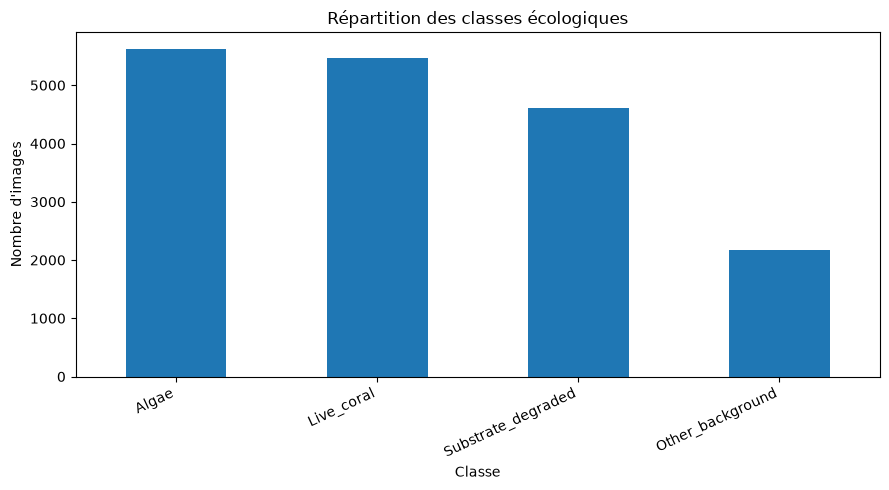

In [6]:
plt.figure(figsize=(9, 5))
class_counts.plot(kind='bar')
plt.title('Répartition des classes écologiques')
plt.xlabel('Classe')
plt.ylabel("Nombre d'images")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'repartition_classes_ecologiques.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

## 5. Identification de l'image originale

Les noms finissent généralement par `_1.png`, `_2.png`, etc. Ce suffixe est supprimé afin que tous les patches d'une même image restent dans le même ensemble.

In [7]:
def extract_original_image_id(filename: str) -> str:
    return re.sub(r'_\d+\.png$', '', filename, flags=re.IGNORECASE)

existing_df['original_image_id'] = existing_df['name'].map(extract_original_image_id)

group_sizes = existing_df.groupby('original_image_id').size()

print("Nombre d'images originales :", existing_df['original_image_id'].nunique())
print('Nombre minimal de patches par image :', int(group_sizes.min()))
print('Nombre maximal de patches par image :', int(group_sizes.max()))
print('Moyenne de patches par image :', round(float(group_sizes.mean()), 2))

display(group_sizes.describe().to_frame('patches_par_image'))

Nombre d'images originales : 1866
Nombre minimal de patches par image : 1
Nombre maximal de patches par image : 10
Moyenne de patches par image : 9.58


,patches_par_image
count,1866.000000
mean,9.576635
std,0.823105
min,1.000000
25%,9.000000
50%,10.000000
75%,10.000000
max,10.000000


## 6. Division train / validation / test par image originale

- 70 % entraînement ;
- 15 % validation ;
- 15 % test.

Aucun identifiant d'image originale ne peut apparaître dans plusieurs ensembles.

In [8]:
gss_train_temp = GroupShuffleSplit(
    n_splits=1, test_size=0.30, random_state=SEED
)

train_indices, temp_indices = next(gss_train_temp.split(
    existing_df,
    y=existing_df['class_id'],
    groups=existing_df['original_image_id']
))

train_df = existing_df.iloc[train_indices].copy()
temp_df = existing_df.iloc[temp_indices].copy()

gss_val_test = GroupShuffleSplit(
    n_splits=1, test_size=0.50, random_state=SEED
)

val_relative_indices, test_relative_indices = next(gss_val_test.split(
    temp_df,
    y=temp_df['class_id'],
    groups=temp_df['original_image_id']
))

val_df = temp_df.iloc[val_relative_indices].copy()
test_df = temp_df.iloc[test_relative_indices].copy()

train_groups = set(train_df['original_image_id'])
val_groups = set(val_df['original_image_id'])
test_groups = set(test_df['original_image_id'])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

for split_name, split_df in [
    ('train', train_df),
    ('validation', val_df),
    ('test', test_df)
]:
    print(f'{split_name:10s}: {len(split_df):5d} patches | '
          f"{split_df['original_image_id'].nunique():4d} images originales")

train     : 12537 patches | 1306 images originales
validation:  2679 patches |  280 images originales
test      :  2654 patches |  280 images originales


,split,ecological_class,count,percentage
0,train,Live_coral,3799,30.302305
1,train,Algae,3987,31.801866
2,train,Substrate_degraded,3195,25.484566
3,train,Other_background,1556,12.411263
4,validation,Live_coral,885,33.034714
5,validation,Algae,814,30.384472
6,validation,Substrate_degraded,648,24.188130
7,validation,Other_background,332,12.392684
8,test,Live_coral,792,29.841748
9,test,Algae,826,31.122833


<Figure size 1000x600 with 0 Axes>

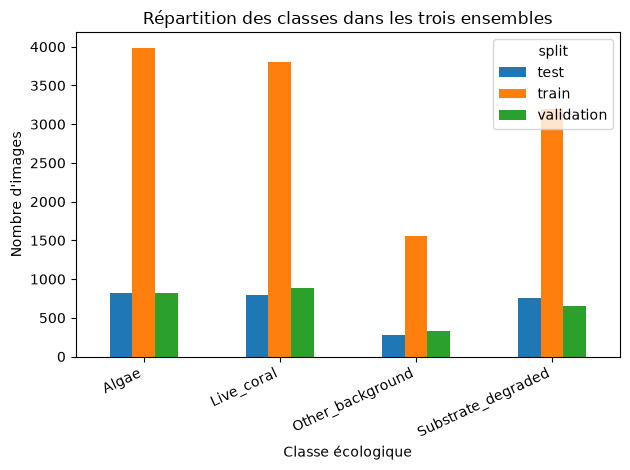

In [9]:
def split_distribution(split_name: str, split_df: pd.DataFrame) -> pd.DataFrame:
    counts = split_df['ecological_class'].value_counts().reindex(CLASS_TO_ID.keys(), fill_value=0)
    percentages = counts / len(split_df) * 100
    return pd.DataFrame({
        'split': split_name,
        'ecological_class': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })

distribution_df = pd.concat([
    split_distribution('train', train_df),
    split_distribution('validation', val_df),
    split_distribution('test', test_df)
], ignore_index=True)

display(distribution_df)

pivot_counts = distribution_df.pivot(
    index='ecological_class', columns='split', values='count'
)

plt.figure(figsize=(10, 6))
pivot_counts.plot(kind='bar')
plt.title('Répartition des classes dans les trois ensembles')
plt.xlabel('Classe écologique')
plt.ylabel("Nombre d'images")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'repartition_train_validation_test.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

## 7. Calcul des poids des classes

In [10]:
class_ids = np.array(sorted(CLASS_TO_ID.values()))
weights = compute_class_weight(
    class_weight='balanced',
    classes=class_ids,
    y=train_df['class_id'].to_numpy()
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}

print('Poids des classes :')
for class_name, class_id in CLASS_TO_ID.items():
    print(f'{class_id} - {class_name:22s}: {class_weights[class_id]:.4f}')

Poids des classes :
0 - Live_coral            : 0.8250
1 - Algae                 : 0.7861
2 - Substrate_degraded    : 0.9810
3 - Other_background      : 2.0143


## 8. Sauvegarde des données préparées

In [11]:
columns_to_save = [
    'name', 'patch_path', 'full_path', 'label',
    'ecological_class', 'class_id', 'original_image_id'
]

mapped_path = PROCESSED_DIR / 'module3_annotations_mapped.csv'
train_path = PROCESSED_DIR / 'module3_train.csv'
val_path = PROCESSED_DIR / 'module3_validation.csv'
test_path = PROCESSED_DIR / 'module3_test.csv'

existing_df[columns_to_save].to_csv(
    mapped_path, index=False, encoding='utf-8-sig'
)
train_df[columns_to_save].to_csv(
    train_path, index=False, encoding='utf-8-sig'
)
val_df[columns_to_save].to_csv(
    val_path, index=False, encoding='utf-8-sig'
)
test_df[columns_to_save].to_csv(
    test_path, index=False, encoding='utf-8-sig'
)

distribution_df.to_csv(
    RESULTS_DIR / 'distribution_splits.csv',
    index=False,
    encoding='utf-8-sig'
)

metadata = {
    'class_to_id': CLASS_TO_ID,
    'class_weights': class_weights,
    'seed': SEED,
    'split_strategy': 'GroupShuffleSplit by original_image_id',
    'train_patches': int(len(train_df)),
    'validation_patches': int(len(val_df)),
    'test_patches': int(len(test_df)),
    'train_original_images': int(train_df['original_image_id'].nunique()),
    'validation_original_images': int(val_df['original_image_id'].nunique()),
    'test_original_images': int(test_df['original_image_id'].nunique()),
    'important_limitation': (
        'The source is named ReefNet RSG TestDataset and is reused here as a proof of concept.'
    )
}

metadata_path = PROCESSED_DIR / 'module3_metadata.json'
metadata_path.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print('✅ Fichier complet :', mapped_path)
print('✅ Train :', train_path)
print('✅ Validation :', val_path)
print('✅ Test :', test_path)
print('✅ Métadonnées :', metadata_path)

✅ Fichier complet : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module3_annotations_mapped.csv
✅ Train : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module3_train.csv
✅ Validation : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module3_validation.csv
✅ Test : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module3_test.csv
✅ Métadonnées : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module3_metadata.json


## Résultat attendu

Dans `data/processed/` :

- `module3_annotations_mapped.csv`
- `module3_train.csv`
- `module3_validation.csv`
- `module3_test.csv`
- `module3_metadata.json`

Dans `results/module3/` :

- `repartition_classes_ecologiques.png`
- `repartition_train_validation_test.png`
- `distribution_splits.csv`
- liste éventuelle des images manquantes ou corrompues.

Après validation de ces résultats, l'étape suivante sera l'entraînement de MobileNetV2.